In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/Multimedia_Authentication"

FRAMES_DIR = os.path.join(PROJECT_DIR, "frames")
SPLIT_FILE = os.path.join(
    PROJECT_DIR,
    "splits",
    "ffpp_6000_split.csv"
)

df = pd.read_csv(SPLIT_FILE)

print("Videos:", len(df))
print("Frame directory:", FRAMES_DIR)
print("Split distribution:")
print(df["split"].value_counts())

Videos: 6000
Frame directory: /content/drive/MyDrive/Multimedia_Authentication/frames
Split distribution:
split
train    4200
val       900
test      900
Name: count, dtype: int64


In [ ]:
frame_files = [
    f for f in os.listdir(FRAMES_DIR)
    if f.endswith(".npz")
]

print("NPZ files:", len(frame_files))
print(frame_files[:10])

NPZ files: 2647
['original__292.npz', 'NeuralTextures__641_662.npz', 'FaceShifter__437_360.npz', 'FaceSwap__666_656.npz', 'FaceSwap__112_892.npz', 'NeuralTextures__015_919.npz', 'Deepfakes__580_524.npz', 'Deepfakes__961_069.npz', 'original__091.npz', 'Deepfakes__620_619.npz']


In [ ]:
PROGRESS_FILE = os.path.join(
    PROJECT_DIR,
    "metadata",
    "frame_extraction_progress.csv"
)

progress_df = pd.read_csv(PROGRESS_FILE)

print("Rows:", len(progress_df))
print(progress_df["status"].value_counts())

Rows: 6000
status
success    6000
Name: count, dtype: int64


In [ ]:
sample_file = os.path.join(FRAMES_DIR, frame_files[0])

data = np.load(sample_file)
frames = data["frames"]

print("File:", frame_files[0])
print("Shape:", frames.shape)
print("Dtype:", frames.dtype)

File: original__292.npz
Shape: (8, 224, 224, 3)
Dtype: uint8


In [ ]:
def make_output_name(file_path):
    return file_path.replace("/", "__").replace("\\", "__").replace(".mp4", ".npz")

In [ ]:
# Check how many expected .npz files actually exist

existing_files = set(os.listdir(FRAMES_DIR))

missing = []

for _, row in progress_df.iterrows():
    expected_name = make_output_name(row["File Path"])

    if expected_name not in existing_files:
        missing.append(row["File Path"])

print("Videos in progress CSV:", len(progress_df))
print("Successful:", (progress_df["status"] == "success").sum())
print("Actual NPZ files:", len(frame_files))
print("Missing NPZ files:", len(missing))

print("\nFirst 20 missing files:")
print(missing[:20])

Videos in progress CSV: 6000
Successful: 6000
Actual NPZ files: 2647
Missing NPZ files: 3353

First 20 missing files:
['original/500.mp4', 'Face2Face/944_032.mp4', 'Face2Face/024_073.mp4', 'FaceSwap/350_349.mp4', 'original/748.mp4', 'original/215.mp4', 'original/362.mp4', 'NeuralTextures/589_565.mp4', 'original/406.mp4', 'FaceSwap/279_298.mp4', 'Face2Face/398_457.mp4', 'NeuralTextures/712_716.mp4', 'FaceShifter/254_261.mp4', 'original/026.mp4', 'Face2Face/264_271.mp4', 'Deepfakes/941_940.mp4', 'FaceShifter/176_190.mp4', 'FaceShifter/045_889.mp4', 'FaceShifter/064_991.mp4', 'original/237.mp4']


In [ ]:
processed_df = check_df[check_df["extracted"]].copy()

PROCESSED_SPLIT_FILE = os.path.join(
    PROJECT_DIR,
    "splits",
    "ffpp_2647_processed_split.csv"
)

processed_df.to_csv(
    PROCESSED_SPLIT_FILE,
    index=False
)

print("Saved:", PROCESSED_SPLIT_FILE)
print("Videos:", len(processed_df))
print(pd.crosstab(processed_df["split"], processed_df["Label"]))

Saved: /content/drive/MyDrive/Multimedia_Authentication/splits/ffpp_2647_processed_split.csv
Videos: 2647
Label  FAKE  REAL
split            
test    359    65
train  1519   303
val     333    68


In [ ]:
# Load the final list of videos for this experiment

processed_df = pd.read_csv(PROCESSED_SPLIT_FILE)

print("Total videos:", len(processed_df))
print("\nSplit distribution:")
print(processed_df["split"].value_counts())

print("\nLabel distribution:")
print(processed_df["Label"].value_counts())

print("\nSplit × Label:")
print(
    pd.crosstab(
        processed_df["split"],
        processed_df["Label"]
    )
)

Total videos: 2647

Split distribution:
split
train    1822
test      424
val       401
Name: count, dtype: int64

Label distribution:
Label
FAKE    2211
REAL     436
Name: count, dtype: int64

Split × Label:
Label  FAKE  REAL
split            
test    359    65
train  1519   303
val     333    68


In [ ]:
FACES_DIR = os.path.join(
    PROJECT_DIR,
    "faces"
)

os.makedirs(FACES_DIR, exist_ok=True)

print("Face data will be stored at:")
print(FACES_DIR)

Face data will be stored at:
/content/drive/MyDrive/Multimedia_Authentication/faces


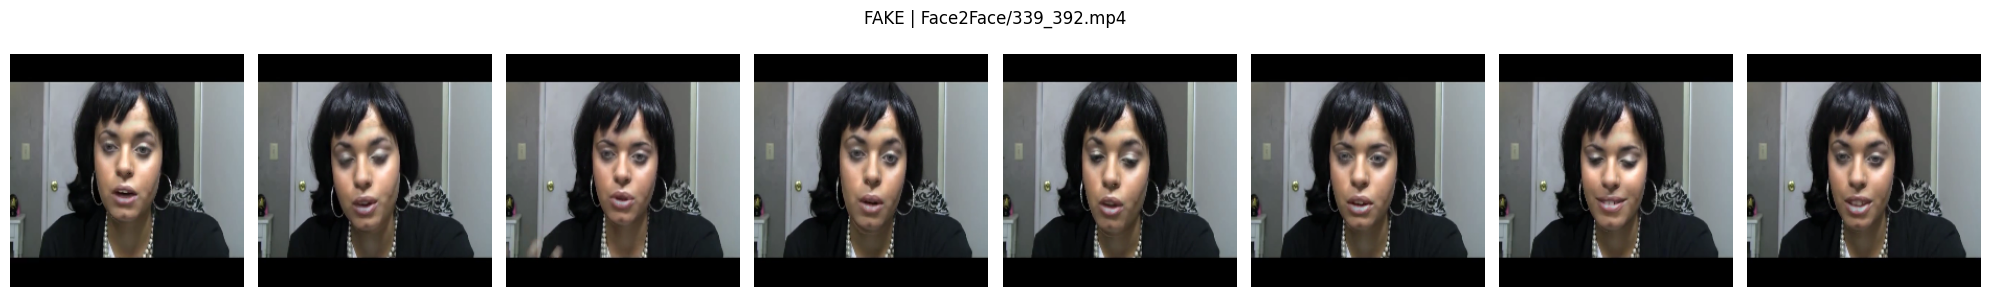

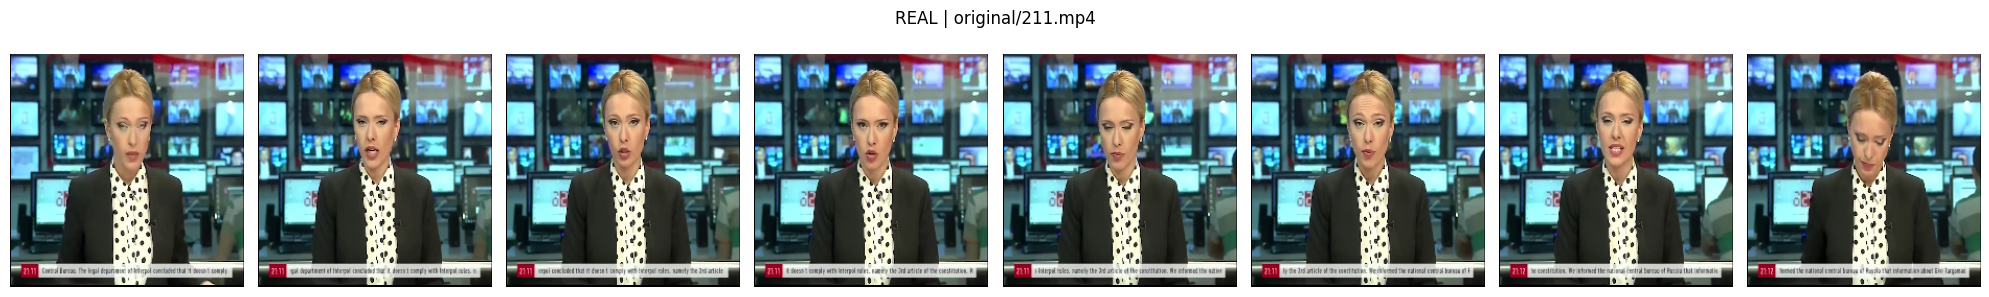

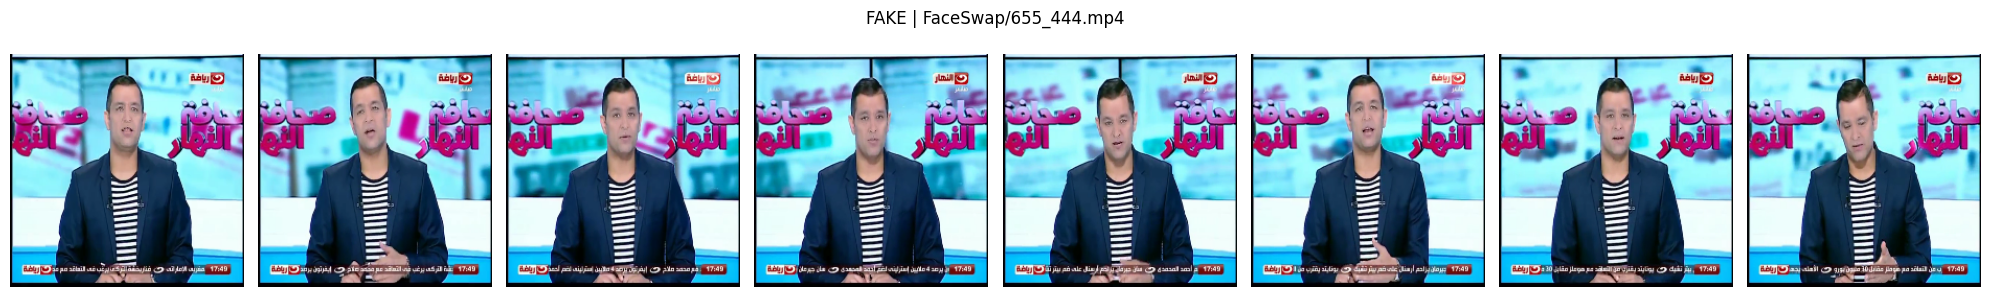

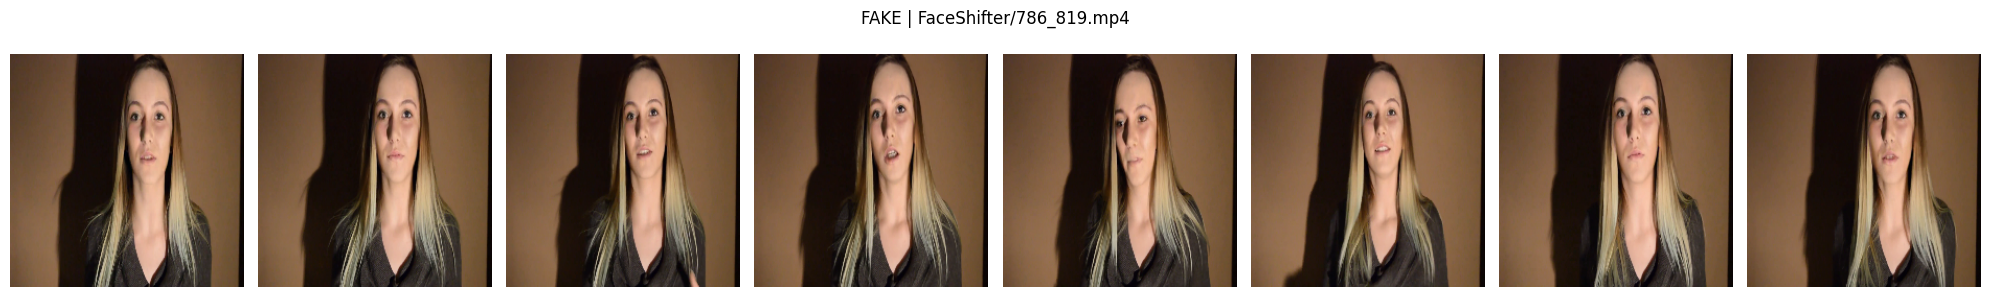

In [ ]:
import random

sample_rows = processed_df.sample(
    n=4,
    random_state=42
)

for _, row in sample_rows.iterrows():

    npz_name = make_output_name(row["File Path"])
    npz_path = os.path.join(FRAMES_DIR, npz_name)

    data = np.load(npz_path)
    frames = data["frames"]

    fig, axes = plt.subplots(
        1, 8,
        figsize=(20, 3)
    )

    for i in range(8):
        axes[i].imshow(frames[i])
        axes[i].axis("off")

    fig.suptitle(
        f'{row["Label"]} | {row["File Path"]}',
        fontsize=12
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import mediapipe as mp

print("MediaPipe version:", getattr(mp, "__version__", "unknown"))
print("MediaPipe location:", mp.__file__)

MediaPipe version: 1.0.1
MediaPipe location: /usr/local/lib/python3.13/dist-packages/mediapipe/__init__.py


In [ ]:
print(dir(mp)[:30])

['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [24]:
!wget -q https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite \
    -O /content/blaze_face_short_range.tflite

print("Model downloaded:",
      os.path.exists("/content/blaze_face_short_range.tflite"))

Model downloaded: True


In [25]:
import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("MediaPipe:", mp.__version__)

MediaPipe: 1.0.1


In [26]:
base_options = python.BaseOptions(
    model_asset_path="/content/blaze_face_short_range.tflite"
)

options = vision.FaceDetectorOptions(
    base_options=base_options,
    min_detection_confidence=0.5
)

detector = vision.FaceDetector.create_from_options(options)

print("Face detector ready.")

Face detector ready.


In [27]:
def detect_face_mediapipe(frame):
    """
    Detect the largest face in an RGB NumPy frame.
    Returns (x, y, w, h) or None.
    """

    # MediaPipe expects uint8 RGB
    frame = np.ascontiguousarray(frame, dtype=np.uint8)

    mp_image = mp.Image(
        image_format=mp.ImageFormat.SRGB,
        data=frame
    )

    result = detector.detect(mp_image)

    if not result.detections:
        return None

    h, w, _ = frame.shape

    best_box = None
    best_area = 0

    for detection in result.detections:

        bbox = detection.bounding_box

        x = max(0, bbox.origin_x)
        y = max(0, bbox.origin_y)

        bw = min(bbox.width, w - x)
        bh = min(bbox.height, h - y)

        area = bw * bh

        if area > best_area:
            best_area = area
            best_box = (x, y, bw, bh)

    return best_box

In [30]:
test_row = processed_df.iloc[0]

npz_name = make_output_name(
    test_row["File Path"]
)

npz_path = os.path.join(
    FRAMES_DIR,
    npz_name
)

data = np.load(npz_path)
test_frames = data["frames"]

print("Video:", test_row["File Path"])
print("Label:", test_row["Label"])
print("Frames:", test_frames.shape)

Video: FaceShifter/424_408.mp4
Label: FAKE
Frames: (8, 224, 224, 3)


In [31]:
boxes = []

for frame in test_frames:
    box = detect_face_mediapipe(frame)
    boxes.append(box)

for i, box in enumerate(boxes):
    print(f"Frame {i+1}: {box}")

Frame 1: (91, 44, 46, 46)
Frame 2: (88, 51, 49, 49)
Frame 3: (88, 48, 48, 48)
Frame 4: (88, 48, 50, 50)
Frame 5: (89, 43, 49, 49)
Frame 6: (88, 43, 51, 51)
Frame 7: (88, 46, 49, 49)
Frame 8: (88, 50, 50, 50)


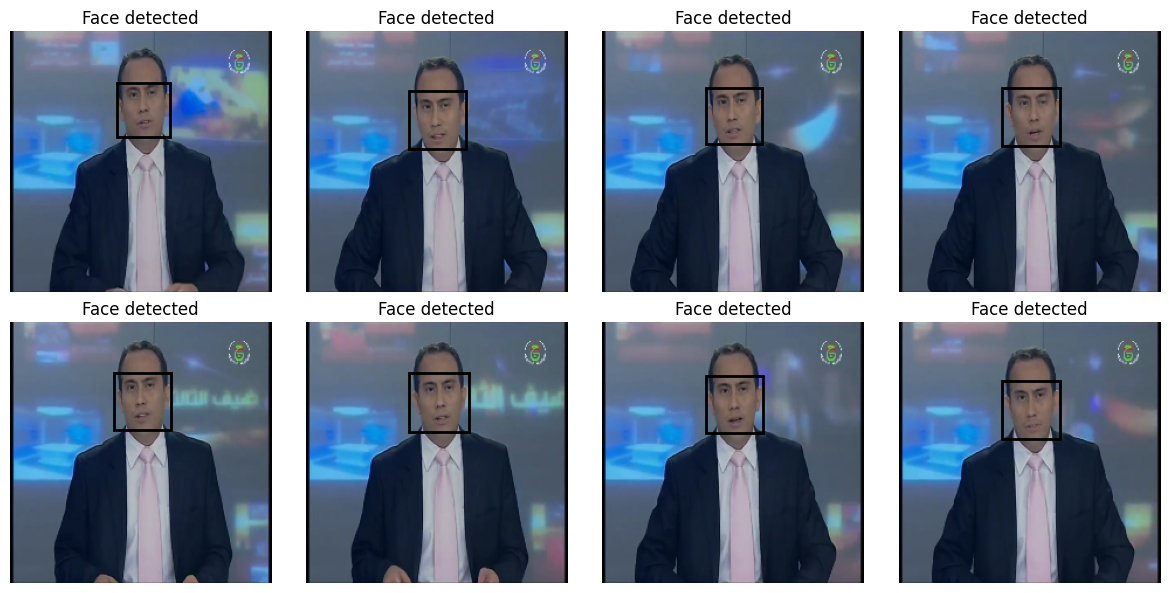

In [32]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

for i, (frame, box) in enumerate(zip(test_frames, boxes)):

    axes[i].imshow(frame)

    if box is not None:
        x, y, w, h = box

        rect = plt.Rectangle(
            (x, y),
            w,
            h,
            fill=False,
            linewidth=2
        )

        axes[i].add_patch(rect)

    axes[i].axis("off")
    axes[i].set_title(
        "Face detected" if box else "NO FACE"
    )

plt.tight_layout()
plt.show()

In [33]:
import cv2

In [34]:
def crop_face(frame, box, margin=0.20, output_size=(224, 224)):
    """
    Crop detected face with a margin and resize.
    """

    if box is None:
        return None

    x, y, w, h = box

    H, W, _ = frame.shape

    # Add margin around bounding box
    mx = int(w * margin)
    my = int(h * margin)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)

    x2 = min(W, x + w + mx)
    y2 = min(H, y + h + my)

    face = frame[y1:y2, x1:x2]

    if face.size == 0:
        return None

    face = cv2.resize(
        face,
        output_size,
        interpolation=cv2.INTER_AREA
    )

    return face

In [35]:
cropped_faces = []

for frame, box in zip(test_frames, boxes):

    face = crop_face(
        frame,
        box,
        margin=0.20
    )

    cropped_faces.append(face)

print("Successfully cropped:",
      sum(face is not None for face in cropped_faces))

print("Shape:",
      cropped_faces[0].shape)

Successfully cropped: 8
Shape: (224, 224, 3)


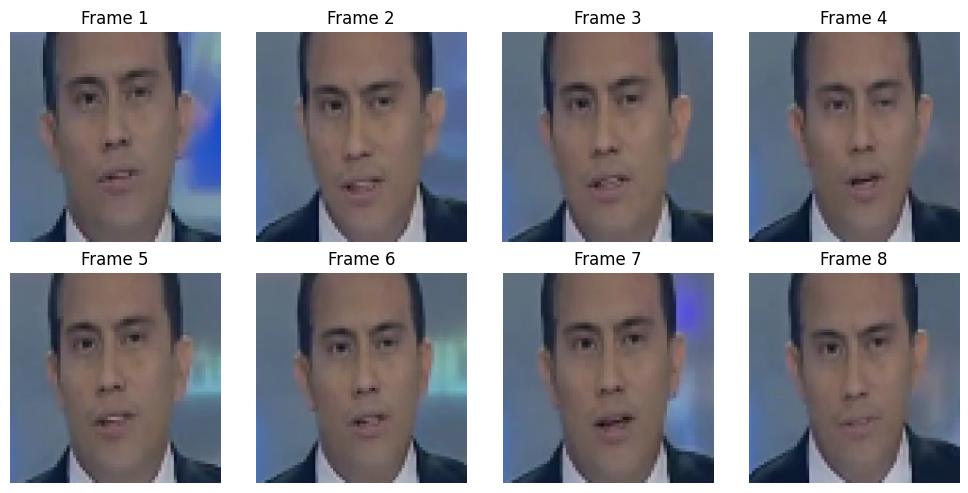

In [36]:
fig, axes = plt.subplots(
    2, 4,
    figsize=(10, 5)
)

axes = axes.flatten()

for i, face in enumerate(cropped_faces):

    if face is not None:
        axes[i].imshow(face)

    axes[i].axis("off")
    axes[i].set_title(f"Frame {i+1}")

plt.tight_layout()
plt.show()

In [37]:
FACES_DIR = os.path.join(
    PROJECT_DIR,
    "faces"
)

os.makedirs(FACES_DIR, exist_ok=True)

print(FACES_DIR)

/content/drive/MyDrive/Multimedia_Authentication/faces


In [38]:
import time

sample_50 = processed_df.sample(
    n=min(50, len(processed_df)),
    random_state=42
)

start_time = time.time()

successful = 0
failed = 0

for _, row in sample_50.iterrows():

    npz_name = make_output_name(row["File Path"])
    npz_path = os.path.join(FRAMES_DIR, npz_name)

    try:
        data = np.load(npz_path)
        frames = data["frames"]

        face_sequence = []

        for frame in frames:

            box = detect_face_mediapipe(frame)

            face = crop_face(
                frame,
                box,
                margin=0.20
            )

            if face is None:
                break

            face_sequence.append(face)

        if len(face_sequence) != 8:
            failed += 1
            continue

        face_sequence = np.array(
            face_sequence,
            dtype=np.uint8
        )

        output_path = os.path.join(
            FACES_DIR,
            npz_name
        )

        np.savez_compressed(
            output_path,
            frames=face_sequence
        )

        successful += 1

    except Exception as e:
        failed += 1
        print("Error:", row["File Path"], e)

elapsed = time.time() - start_time

print(f"\nSuccessful: {successful}")
print(f"Failed: {failed}")
print(f"Time: {elapsed:.2f} seconds")
print(f"Time/video: {elapsed/len(sample_50):.2f} seconds")
print(f"Estimated full dataset: {elapsed/len(sample_50)*len(processed_df)/60:.1f} minutes")


Successful: 49
Failed: 1
Time: 53.18 seconds
Time/video: 1.06 seconds
Estimated full dataset: 46.9 minutes


In [40]:
for _, row in sample_50.iterrows():
    npz_name = make_output_name(row["File Path"])
    face_path = os.path.join(FACES_DIR, npz_name)

    if not os.path.exists(face_path):
        print("Not processed:", row["File Path"])

Not processed: FaceShifter/105_180.mp4


In [41]:
FACE_PROGRESS_FILE = os.path.join(
    PROJECT_DIR,
    "metadata",
    "face_preprocessing_progress.csv"
)

if os.path.exists(FACE_PROGRESS_FILE):
    face_progress = pd.read_csv(FACE_PROGRESS_FILE)
    print("Existing face progress loaded.")
else:
    face_progress = processed_df[
        ["File Path", "Label", "split"]
    ].copy()

    face_progress["status"] = "pending"
    face_progress["error"] = ""

    face_progress.to_csv(
        FACE_PROGRESS_FILE,
        index=False
    )

print(face_progress["status"].value_counts())

status
pending    2647
Name: count, dtype: int64


In [42]:
from tqdm.auto import tqdm
import time

SAVE_EVERY = 25

pending_indices = face_progress.index[
    face_progress["status"] == "pending"
]

print("Remaining:", len(pending_indices))

start_time = time.time()

for count, idx in enumerate(
    tqdm(pending_indices, desc="Face preprocessing"),
    start=1
):

    file_path = face_progress.loc[idx, "File Path"]

    npz_name = make_output_name(file_path)

    input_path = os.path.join(
        FRAMES_DIR,
        npz_name
    )

    output_path = os.path.join(
        FACES_DIR,
        npz_name
    )

    try:

        # Already processed?
        if os.path.exists(output_path):
            face_progress.loc[idx, "status"] = "success"
            continue

        data = np.load(input_path)
        frames = data["frames"]

        face_sequence = []

        for frame in frames:

            box = detect_face_mediapipe(frame)

            face = crop_face(
                frame,
                box,
                margin=0.20
            )

            if face is None:
                raise ValueError(
                    "Face not detected in one or more frames"
                )

            face_sequence.append(face)

        face_sequence = np.asarray(
            face_sequence,
            dtype=np.uint8
        )

        # Safety check
        if face_sequence.shape != (8, 224, 224, 3):
            raise ValueError(
                f"Unexpected shape: {face_sequence.shape}"
            )

        np.savez_compressed(
            output_path,
            frames=face_sequence
        )

        # Verify actual file
        if os.path.exists(output_path):
            face_progress.loc[idx, "status"] = "success"
            face_progress.loc[idx, "error"] = ""
        else:
            raise IOError("Output file was not created")

    except Exception as e:

        face_progress.loc[idx, "status"] = "failed"
        face_progress.loc[idx, "error"] = str(e)

    # Save progress
    if count % SAVE_EVERY == 0:

        face_progress.to_csv(
            FACE_PROGRESS_FILE,
            index=False
        )

# Final save
face_progress.to_csv(
    FACE_PROGRESS_FILE,
    index=False
)

elapsed = time.time() - start_time

print("\nFinished!")
print(face_progress["status"].value_counts())
print(f"Time: {elapsed/60:.1f} minutes")

Remaining: 2647


Face preprocessing:   0%|          | 0/2647 [00:00<?, ?it/s]


Finished!
status
success    2580
failed       67
Name: count, dtype: int64
Time: 48.1 minutes


In [43]:
print(face_progress["status"].value_counts())

print(
    "\nActual face files:",
    len([
        f for f in os.listdir(FACES_DIR)
        if f.endswith(".npz")
    ])
)

status
success    2580
failed       67
Name: count, dtype: int64

Actual face files: 2580
